#Image Processing with OpenCV

## Task 1: Color Space Conversion

Using your low-light photo, convert it to Grayscale, HSV, and RGB (remember OpenCV loads as BGR by default). Display all versions side by side.

Then, looking specifically at your own photo, note which HSV channel best preserves detail in the darkest part of the frame, and why you think that's the case for this particular shot.

In [17]:
#import the required libraries

import cv2
import matplotlib.pyplot as plt
import numpy as np

In [44]:
#reading the image in a variable
low_light_img = cv2.imread("/content/Manishraj_lowlight.png")

In [45]:
if low_light_img is None:
    print("Image not found!")
else:
    print("Image loaded successfully.")

Image loaded successfully.


In [46]:
#The image if stroed in BGR formated by default. We can convert them to different versions here

gray_image = cv2.cvtColor(low_light_img,cv2.COLOR_BGR2GRAY)
rgb_image = cv2.cvtColor(low_light_img,cv2.COLOR_BGR2RGB)
hsv_image = cv2.cvtColor(low_light_img,cv2.COLOR_BGR2HSV)

In [48]:
#split the hsv chanbels
h_channel , s_channel , v_channel = cv2.split(hsv_image)

In [51]:
#defining a generic func to display images
def disp_img(images,titles,figsize=(18,5),cmap=None):
  plt.figure(figsize=figsize)
  for i in range(len(images)):
    plt.subplot(1,len(images),i+1)
    if cmap is not None:
      plt.imshow(images[i],cmap=cmap)
    else:
      plt.imshow(images[i])
    plt.title(titles[i])
  plt.show()

In [52]:
#hsv image cannot be directly diaplyed using matplot so we convert it to RGB first

hsv_display = cv2.cvtColor(hsv_image,cv2.COLOR_HSV2RGB)

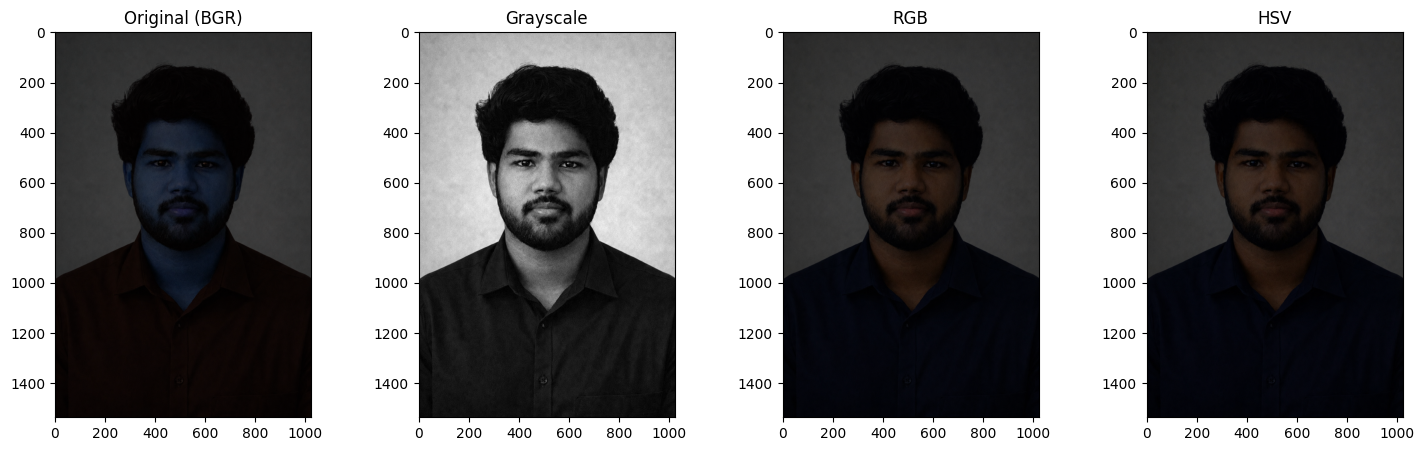

In [54]:
disp_img(
    images=[
        low_light_img,
        gray_image,
        rgb_image,
        hsv_display
    ],
    titles=[
        "Original (BGR)",
        "Grayscale",
        "RGB",
        "HSV"
    ],
    cmap="gray"
)


The low-light image was successfully converted into Grayscale, RGB, and HSV color spaces.

- The Grayscale image removes all color information and represents the image using only intensity values, making facial features and edges easier to observe.

- The RGB image displays the original colors correctly because OpenCV images were converted from the default BGR format to RGB before displaying with Matplotlib.

- The HSV image separates color information (Hue and Saturation) from brightness (Value), making it useful for analyzing illumination changes and image processing tasks.

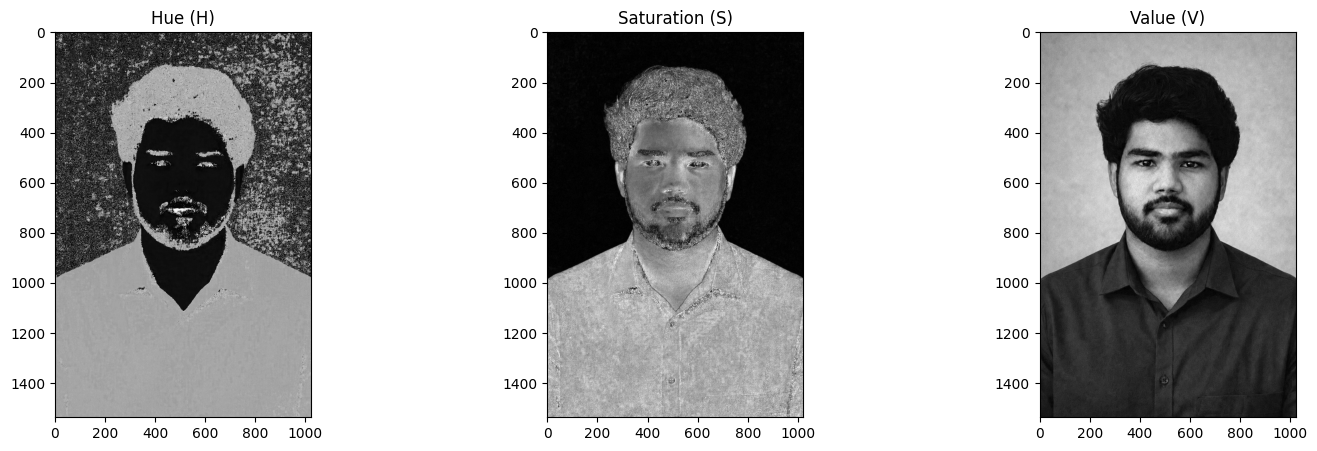

In [56]:
#Displaing each HSV channel as separate image to infer which channel has higher impact in retaing the info

disp_img(
    images=[
        h_channel,
        s_channel,
        v_channel
    ],
    titles=[
        "Hue (H)",
        "Saturation (S)",
        "Value (V)"
    ],
    cmap="gray"
)

- Value (V) channel preserves the most detail in dark areas.

- It represents the brightness (intensity) of the image.
Facial features are more visible in the V channel.

- Hue (H) channel mainly shows color information and becomes noisy in low-light conditions.

- Saturation (S) channel shows color intensity but loses details because the image has very little color in low light.
